# Capstone Project

## Step 1: Data Collection, Cleaning, Preprocessing

In [2]:
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import numpy as np


dataset = load_dataset("BrotherTony/employee-burnout-turnover-prediction-800k")

C:\Users\Mitchell\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Overview of variables from HuggingFace

- Core Identity
    - employee_id Unique synthetic identifier
    - role Job title (300+ varieties)
    - job_level Entry | Mid | Senior | Manager | Lead
    - department Business unit (38 departments)
    - tenure_months Time with company (1-357 months)
- Compensation
    - salary Annual USD ($27K-$384K range)
    - Performance Indicators
    - performance_score Normalized 0-1 rating
    - project_completion_rate Delivery success metric
    - goal_achievement_rate Objective completion
    - role_complexity_score Job difficulty rating
    - career_progression_score Growth trajectory
- Wellbeing & Engagement
    - satisfaction_score Employee happiness (0-1)
    - workload_score Workload burden indicator
    - stress_level Stress assessment (0-1)
    - burnout_risk Burnout probability (0-1)
    - training_participation L&D engagement
    - Collaboration & Communication
    - team_sentiment Team morale (0-1)
    - email_sentiment Email tone analysis
    - slack_activity Chat platform usage
    - meeting_participation Meeting engagement
    - collaboration_score Teamwork rating
    - communication_patterns Persona-based style
- Skills & Competencies
    - technical_skills Array of tech skills (4-9 per employee)
    - soft_skills Array of soft skills (3-7 per employee)
- Attrition & Risk
    - left_company Boolean exit flag
    - turnover_reason Exit category (if applicable)
    - turnover_probability_generated ML-predicted churn risk
    - risk_factors_summary Low | Medium | High | Severe risk
- Behavioral Profiling
    - persona_name 12 archetypes:
        -   OverachievingSprinter
        -   BurntOutStar
        -   QuietAchiever
        -   NewEnthusiast
        -   StrugglingLearner
        -   SteadyEddy
        -   ChangeResistor
        -   SeasonedExpert
        -   SocialCatalyst
        -   9-to-5Clockwatcher
        -   AmbitiousClimber
        -   CorporateNavigator (Persona Names are A.I. generated)
- Qualitative Data
    - recent_feedback Anonymized employee comments (1000+ unique snippets)
    - overtime_hours Extra hours logged (0-74 range)

In [3]:
df = dataset["train"].to_pandas()

df.shape

(849999, 31)

In [4]:
df.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849999 entries, 0 to 849998
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   employee_id                     849999 non-null  object 
 1   role                            849999 non-null  object 
 2   job_level                       849999 non-null  object 
 3   department                      849999 non-null  object 
 4   tenure_months                   849999 non-null  int64  
 5   salary                          849999 non-null  float64
 6   performance_score               849999 non-null  float64
 7   satisfaction_score              849999 non-null  float64
 8   workload_score                  849999 non-null  float64
 9   team_sentiment                  849999 non-null  float64
 10  recent_feedback                 849999 non-null  object 
 11  communication_patterns          849999 non-null  object 
 12  project_completi

In [15]:
df.isnull().sum()

employee_id                       0
role                              0
job_level                         0
department                        0
tenure_months                     0
salary                            0
performance_score                 0
satisfaction_score                0
workload_score                    0
team_sentiment                    0
recent_feedback                   0
communication_patterns            0
project_completion_rate           0
overtime_hours                    0
training_participation            0
collaboration_score               0
technical_skills                  0
soft_skills                       0
email_sentiment                   0
slack_activity                    0
meeting_participation             0
goal_achievement_rate             0
stress_level                      0
burnout_risk                      0
left_company                      0
turnover_reason                   0
risk_factors_summary              0
turnover_probability_generat

### Initial Overview
Row Count: 849,999
Column Count: 31
NA Values: 0

In [16]:
df.dtypes.value_counts()

float64    18
object     11
int64       1
bool        1
Name: count, dtype: int64

In [17]:
df["left_company"].value_counts()

left_company
False    607473
True     242526
Name: count, dtype: int64

In [18]:
df["left_company"].value_counts(normalize=True)

left_company
False    0.714675
True     0.285325
Name: proportion, dtype: float64

### Target Variable
The target variable has a mild split. I belive the route I will take is to use train_test_splits stratify y to just be sure the proportions in the train and test splits are equal for the target variable. If later I run into issues with poor model results I may reevaluate.

In [19]:
df.dtypes

employee_id                        object
role                               object
job_level                          object
department                         object
tenure_months                       int64
salary                            float64
performance_score                 float64
satisfaction_score                float64
workload_score                    float64
team_sentiment                    float64
recent_feedback                    object
communication_patterns             object
project_completion_rate           float64
overtime_hours                    float64
training_participation            float64
collaboration_score               float64
technical_skills                   object
soft_skills                        object
email_sentiment                   float64
slack_activity                    float64
meeting_participation             float64
goal_achievement_rate             float64
stress_level                      float64
burnout_risk                      

In [20]:
df.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [21]:
df["job_level"].unique()

array(['Mid', 'Manager', 'Entry', 'Senior', 'Lead'], dtype=object)

In [22]:
df["role"].unique()

array([' ', ' Customer Success Manager', ' Administrative Assistant',
       ' Senior Manager', ' Anonymous Employee',
       ' Senior Business Analyst', ' Sales', ' Support Worker',
       ' Customer Advisor', ' Senior Consultant', ' Manager',
       ' Sales Assistant', ' Consultant', ' Team Member',
       ' Project Manager', 'Production Technician I',
       ' Software Development Engineer II', ' Accountant',
       ' Audit Associate', 'Former Employee - Anonymous Employee',
       ' Crew Member/Grill Cook', ' Customer Service Representative',
       ' Crew Member', ' Customer Service Assistant', ' IT Consultant',
       ' Retail Sales Assistant', ' Business Manager',
       ' Research Associate', ' Analyst', ' Tax Associate', ' Lecturer',
       ' Audit Senior Associate', ' Audit Manager', 'Software Engineer',
       ' Operations Analyst', ' Director', ' Assistant Manager',
       ' Housekeeper', ' Software Engineer', ' Specialist',
       'Sales Executive', ' Senior Associate', ' 

In [23]:
df["role"].value_counts()

role
 Anonymous Employee                      224117
                                         109047
Current Employee - Anonymous Employee     21989
 Manager                                  20440
 Consultant                               17308
                                          ...  
 Technical Consultant                       373
 Operations Specialist                      369
 Security Officer                           353
 Actuarial Analyst                          350
 Driver                                     346
Name: count, Length: 300, dtype: int64

Removal of role column as well because majority are NA values

## Variable Reduction
- employee_id - Employee Indicator Number
- burnout_risk - Unreasonable to have
- turnover_reason - Clear leakage, if there is a reason the model will know the employee left
- risk_factors_summary - Categorizes into a risk factor summary, this is something we would want to create on our own
- turnover_probability_generated - Again, this is something we are trying to compute with the model
- persona_name - Again, a persona might be something we create from analysis of the data
- communication_patters - This again seemed to be a summary gained from previous analysis. I believe I can create more believable ones simply from doing some analysis on things like recent_feedback
- role - Many unique roles, much of the data is captured in job_level and department variables (Example: Role (Senior Manager) Job_level (Manager) department (R&D)

In [24]:
df_clean = df.drop(["employee_id", "burnout_risk", "turnover_reason", "risk_factors_summary", "turnover_probability_generated", "persona_name","communication_patterns", "role"], axis=1)
df_clean.head()

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
0,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,...,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.492131,0.492131,0.632482,0.908992,False,0.2,1.000000
1,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,...,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.981394,0.981394,0.538587,0.363321,False,0.2,1.000000
2,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,...,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.701138,0.701138,0.624656,0.664378,True,0.2,0.836495
3,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.339626,0.339626,0.959320,1.000000,False,0.2,1.000000
4,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,...,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.565582,0.565582,0.677305,0.723049,False,0.2,1.000000


In [25]:
df_clean.columns

Index(['job_level', 'department', 'tenure_months', 'salary',
       'performance_score', 'satisfaction_score', 'workload_score',
       'team_sentiment', 'recent_feedback', 'project_completion_rate',
       'overtime_hours', 'training_participation', 'collaboration_score',
       'technical_skills', 'soft_skills', 'email_sentiment', 'slack_activity',
       'meeting_participation', 'goal_achievement_rate', 'stress_level',
       'left_company', 'role_complexity_score', 'career_progression_score'],
      dtype='object')

In [26]:
df_clean.dtypes

job_level                    object
department                   object
tenure_months                 int64
salary                      float64
performance_score           float64
satisfaction_score          float64
workload_score              float64
team_sentiment              float64
recent_feedback              object
project_completion_rate     float64
overtime_hours              float64
training_participation      float64
collaboration_score         float64
technical_skills             object
soft_skills                  object
email_sentiment             float64
slack_activity              float64
meeting_participation       float64
goal_achievement_rate       float64
stress_level                float64
left_company                   bool
role_complexity_score       float64
career_progression_score    float64
dtype: object

## Variable Encoding

In [27]:
df_clean.select_dtypes(exclude="number").columns

Index(['job_level', 'department', 'recent_feedback', 'technical_skills',
       'soft_skills', 'left_company'],
      dtype='object')

In [28]:
encoding_table = pd.DataFrame({
    "Variable": [
        "department",
        "job_level",
        "recent_feedback",
        "technical_skills",
        "soft_skills"
    ],
    "Encoding": [
        "One Hot Encode",
        "Ordinal Encode",
        "Feature Engineer Later",
        "Feature Engineer Later",
        "Feature Engineer Later",
    ]
})

print(encoding_table)

           Variable                Encoding
0        department          One Hot Encode
1         job_level          Ordinal Encode
2   recent_feedback  Feature Engineer Later
3  technical_skills  Feature Engineer Later
4       soft_skills  Feature Engineer Later


In [29]:
df_clean["department"].unique()

array(['Research & Development', 'HR', 'Dairy', 'Procurement', 'Meats',
       'Sales & Marketing', 'Technology', 'Operations', 'Sales', 'Legal',
       'Processed Foods', 'R&D', 'Analytics', 'Produce',
       'Customer Service', 'Production       ', 'Bakery', 'Finance',
       'Human Resources', 'Admin Offices', 'nan', 'Store Management',
       'HR Technology', 'IT/IS', 'Software Engineering', 'Audit',
       'Accounts Receiveable', 'Labor Relations', 'Training',
       'Investment', 'Accounting', 'Accounts Payable', 'Compensation',
       'Information Technology', 'Recruitment', 'Executive',
       'Executive Office', 'Employee Records'], dtype=object)

In [30]:
df_clean["job_level"].unique()

array(['Mid', 'Manager', 'Entry', 'Senior', 'Lead'], dtype=object)

Job level looks to be in great shape. I will clean up department as there are issues here.

In [31]:
df_clean["department"].value_counts()

department
Sales & Marketing         155390
Research & Development    101963
Operations                101176
Technology                 64037
Procurement                63979
Analytics                  49011
Sales                      48980
Customer Service           36774
Meats                      32376
Dairy                      32370
Bakery                     30759
Produce                    24426
HR                         23018
Finance                    23011
Processed Foods            15664
Production                 13326
Legal                       9400
R&D                         9228
Human Resources             6569
IT/IS                       2145
nan                          983
Store Management             871
Software Engineering         454
Admin Offices                420
Accounting                   370
Accounts Receiveable         360
Training                     336
Recruitment                  323
Audit                        320
Accounts Payable             317

In [32]:
# Clean and Combine departments that are either similar or the same

df_clean["department"] = df_clean["department"].str.strip()
df_clean["department"] = df_clean["department"].replace({
    "Human Resources": "HR",
    "HR Technology": "HR",
    "Research & Development": "R&D",
    "Technology": "IT",
    "IT/IS": "IT",
    "Software Engineering": "IT",
    "Information Technology": "IT",
    "Accounts Receiveable": "Accounting",
    "Accounts Payable": "Accounting",
    "nan": "Unknown",
    "Executive Office": "Executive",
    "Dairy": "Grocery",
    "Meats": "Grocery",
    "Bakery": "Grocery",
    "Processed Foods": "Grocery",
    "Produce": "Grocery",
    "Compensation": "HR",
    "Recruitment": "HR",
    "Employee Records": "HR",
    "Audit": "Accounting",
    "Labor Relations": "HR",
    "Training": "HR",
    "Sales": "Sales & Marketing",
    "Investment": "Finance",
    "Admin Offices": "Executive"
})

In [33]:
df_clean["department"].unique()

array(['R&D', 'HR', 'Grocery', 'Procurement', 'Sales & Marketing', 'IT',
       'Operations', 'Legal', 'Analytics', 'Customer Service',
       'Production', 'Finance', 'Executive', 'Unknown',
       'Store Management', 'Accounting'], dtype=object)

In [34]:
df_clean["department"].value_counts()

department
Sales & Marketing    204370
Grocery              135595
R&D                  111191
Operations           101176
IT                    66856
Procurement           63979
Analytics             49011
Customer Service      36774
HR                    31225
Finance               23196
Production            13326
Legal                  9400
Accounting             1367
Unknown                 983
Store Management        871
Executive               679
Name: count, dtype: int64

## Numeric Data Overview

In [35]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure_months,849999.0,70.380999,50.177033,1.000000,30.000000,67.000000,105.000000,357.000000
salary,849999.0,84563.069751,47444.308564,27190.569289,41006.776951,78178.525918,116146.639606,384330.428656
performance_score,849999.0,0.692027,0.183911,0.074113,0.571340,0.699235,0.825585,1.000000
satisfaction_score,849999.0,0.581941,0.276268,0.050000,0.367016,0.583188,0.813912,1.000000
workload_score,849999.0,0.599490,0.200038,0.006741,0.455657,0.613744,0.756693,0.999615
team_sentiment,849999.0,0.666848,0.178232,0.019774,0.545729,0.686320,0.806540,0.999956
project_completion_rate,849999.0,0.595412,0.161173,0.059290,0.490179,0.609499,0.716149,1.000000
overtime_hours,849999.0,3.132903,6.094207,0.000000,0.000000,0.000000,4.161240,73.953574
training_participation,849999.0,0.279344,0.221602,0.000079,0.103691,0.223123,0.400716,1.000000
collaboration_score,849999.0,0.473380,0.184961,0.008674,0.332366,0.457102,0.600885,1.000000


Text(0.5, 1.0, 'Salary')

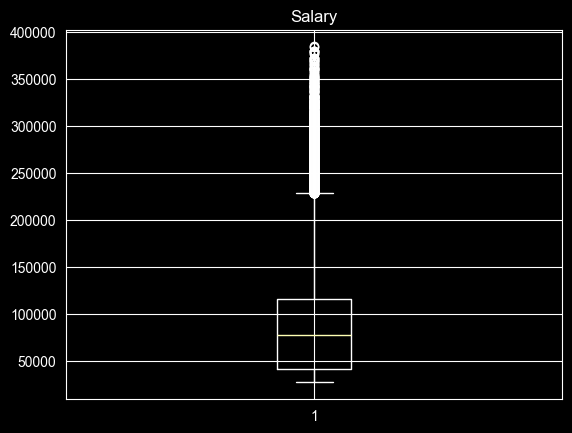

In [42]:
plt.boxplot(df_clean["salary"])
plt.title("Salary")

Text(0.5, 1.0, 'Overtime')

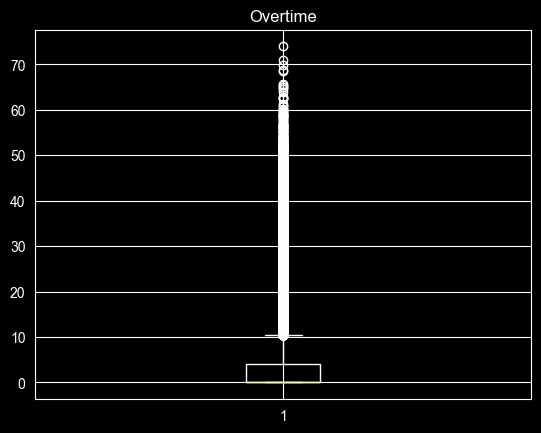

In [43]:
plt.boxplot(df_clean["overtime_hours"])
plt.title("Overtime")

In [38]:
df_clean["overtime_hours"].quantile([0.95,0.99,0.995,0.999])

0.950    16.469986
0.990    26.415813
0.995    30.480404
0.999    39.678071
Name: overtime_hours, dtype: float64

In [39]:
# Overtime IQR
Q1 = df_clean["overtime_hours"].quantile(0.25)
Q3 = df_clean["overtime_hours"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["overtime_hours"] > upper) | (df_clean["overtime_hours"] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
15,Mid,Operations,106,30555.117342,1.000000,0.965974,0.368575,0.657452,Excellent Starting Point and Career Experience...,0.873715,...,"[Python (Pandas, NumPy, SciPy), Go, Linux/Unix...","[Creativity, Teamwork, Mentorship, Leadership,...",1.000000,0.657452,0.657452,1.000000,0.631425,False,0.2,1.000000
21,Mid,IT,52,75126.049280,0.944274,0.703804,0.333019,0.398434,Great office with great people in Old Town Sco...,0.765003,...,"[Network Security, Kubernetes, Data Modeling, ...","[Teamwork, Time Management, Creativity]",0.714901,0.318919,0.318919,0.944274,0.952080,False,0.2,0.988804
42,Mid,IT,115,95574.323456,0.800380,0.743965,0.286216,0.646333,Love the technology and the peers! An FMCG SCH...,0.640304,...,"[Computer Vision, Express.js, dbt, XGBoost, No...","[Creativity, Problem Solving, Time Management,...",0.719377,0.519369,0.519369,0.800380,1.000000,False,0.2,1.000000
45,Mid,Customer Service,1,48480.314304,0.513699,0.480554,0.292526,0.761085,great company to work Surrounded by smart peop...,0.410959,...,"[Apache Kafka, Ansible, Svelte, Webpack, CSS3]","[Emotional Intelligence, Creativity, Time Mana...",0.480579,0.484359,0.484359,0.513699,1.000000,True,0.2,0.341016
62,Entry,Grocery,50,114170.000218,1.000000,0.987024,0.338931,0.478504,its a wage so it’s manageable Nothing beats wh...,0.800000,...,"[XGBoost, Machine Learning Theory, Computer Vi...","[Mentorship, Adaptability, Communication, Time...",1.000000,0.454579,0.454579,1.000000,1.000000,False,0.2,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849924,Mid,Grocery,146,59082.576768,0.602783,0.996292,0.414990,0.733356,"Good culture, no any issues good brand to sell...",0.565224,...,"[A/B Testing, Express.js, Python (Django, Flas...","[Leadership, Problem Solving, Time Management,...",1.000000,0.733356,0.733356,0.602783,0.585010,True,0.2,1.000000
849925,Entry,Operations,108,173552.201167,1.000000,0.408630,0.367552,0.898103,a company that used to be inspirational The op...,0.800000,...,"[ETL/ELT Pipelines, Java (Spring Boot), dbt, G...","[Adaptability, Mentorship, Critical Thinking, ...",0.393118,0.490744,0.490744,1.000000,1.000000,False,0.2,1.000000
849965,Mid,Operations,52,99627.114862,0.729942,0.997828,0.393323,0.579257,It is one of the leading companies in the worl...,0.682618,...,"[Docker, Python (Pandas, NumPy, SciPy), Networ...","[Problem Solving, Emotional Intelligence, Conf...",1.000000,0.579257,0.579257,0.729942,0.506677,True,0.2,0.781638
849979,Mid,Sales & Marketing,13,42373.340322,0.410077,0.402426,0.449570,0.512177,Very smart and wonderful people. no Apple empl...,0.328062,...,"[Machine Learning Theory, CI/CD Pipelines, Azu...","[Creativity, Leadership, Communication, Adapta...",0.414506,0.302263,0.302263,0.410077,1.000000,True,0.2,0.399205


In [31]:
upper

np.float64(10.4030998235)

In [40]:
# Salary IQR
Q1 = df_clean["salary"].quantile(0.25)
Q3 = df_clean["salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["salary"] > upper) | (df_clean["salary"] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
3,Manager,R&D,31,236066.567114,0.959320,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.339626,0.339626,0.959320,1.000000,False,0.2,1.000000
192,Lead,Sales & Marketing,134,233167.130758,0.299067,0.334554,0.658352,0.412823,You are constantly spied on and talked about b...,0.239254,...,"[Kubernetes, REST APIs, Go, Ansible, Angular, ...","[Communication, Problem Solving, Leadership, C...",0.322961,0.238893,0.238893,0.299067,1.000000,True,0.2,1.000000
223,Mid,R&D,71,230611.714542,0.590959,0.309930,0.709765,0.856910,mid management is extremely inexperienced and ...,0.472767,...,"[A/B Testing, REST APIs, React, Site Reliabili...","[Communication, Critical Thinking, Leadership,...",0.291633,0.432005,0.432005,0.590959,1.000000,True,0.2,0.731313
571,Entry,HR,88,241590.359988,0.898342,0.359893,0.720298,0.567561,its was very good working there in had like it...,0.731480,...,"[C# (.NET), Linux/Unix Administration, Airflow...","[Conflict Resolution, Leadership, Creativity, ...",0.343733,0.291489,0.291489,0.898342,0.935969,False,0.2,1.000000
590,Mid,Grocery,98,237712.166249,0.939641,0.121542,0.554301,0.737120,Great place for students No clear set up and g...,0.751713,...,"[JavaScript (ESNext), HTML5, Computer Vision, ...","[Communication, Emotional Intelligence, Adapta...",0.131678,0.289080,0.289080,0.939641,1.000000,False,0.2,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849035,Manager,Sales & Marketing,41,247870.130985,0.222508,0.872832,0.528911,0.920150,Rotational Team Manager There were some good m...,0.216501,...,"[Python (Django, Flask, FastAPI), Machine Lear...","[Creativity, Leadership, Mentorship]",0.854228,0.867570,0.867570,0.222508,0.807524,False,0.2,0.968968
849131,Mid,Sales & Marketing,47,251125.331455,0.475477,0.168932,0.551889,0.567707,Great Place to Work!! - salary\r\n- work/life ...,0.380381,...,"[Computer Vision, Svelte, Rust, Site Reliabili...","[Creativity, Emotional Intelligence, Mentorshi...",0.169022,0.237481,0.237481,0.475477,1.000000,True,0.2,0.953572
849137,Mid,Grocery,98,232222.528088,0.678457,0.402646,0.680768,0.871581,"SAP Labs outlook, Palo Alto Limited postdoc op...",0.542766,...,"[Machine Learning Theory, Network Security, Py...","[Communication, Time Management, Adaptability,...",0.416303,0.515464,0.515464,0.678457,1.000000,False,0.2,0.887562
849339,Mid,Analytics,67,248938.920548,0.479858,0.347292,0.655568,0.457864,"Cutting Edge Tech, Fast Paced As organization ...",0.383886,...,"[Angular, Terraform, Site Reliability Engineer...","[Critical Thinking, Mentorship, Communication,...",0.349639,0.249420,0.249420,0.479858,1.000000,False,0.2,0.839096


In [41]:
# tenure IQR
Q1 = df_clean['tenure_months'].quantile(0.25)
Q3 = df_clean['tenure_months'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['tenure_months'] > upper) | (df_clean['tenure_months'] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
172,Entry,Sales & Marketing,221,122204.588278,0.631789,0.219018,0.815754,0.166221,"Pay, bonuses impacted by wider firm Lack of ca...",0.505431,...,"[Machine Learning Theory, A/B Testing, R, Kube...","[Emotional Intelligence, Conflict Resolution, ...",0.197452,0.069199,0.069199,0.631789,1.000000,False,0.2,1.0
1052,Mid,R&D,226,115917.662113,0.645903,0.864114,0.780918,0.460919,"Great place to work, lower salary than Google ...",0.601238,...,"[GraphQL, Network Security, GCP, Ruby on Rails...","[Emotional Intelligence, Conflict Resolution, ...",0.874521,0.420434,0.420434,0.645903,0.577424,False,0.2,1.0
1123,Manager,Procurement,219,30229.596717,0.837655,0.496788,0.679374,0.773964,"Great company, better with Satya! No pressure,...",0.670124,...,"[Python (Django, Flask, FastAPI), SQL, Express...","[Mentorship, Emotional Intelligence, Adaptabil...",0.490760,0.522974,0.522974,0.837655,1.000000,True,0.2,1.0
1619,Mid,Sales & Marketing,268,28954.574543,0.690717,0.153649,0.640812,0.794254,"Awesome company, long days. Bad teacher and I ...",0.552574,...,"[Rust, TypeScript, Azure, JavaScript (ESNext)]","[Mentorship, Creativity, Problem Solving]",0.191853,0.344942,0.344942,0.690717,1.000000,False,0.6,1.0
1883,Mid,R&D,221,55305.081641,0.639198,0.428775,0.387232,0.721160,"Good pay &amp; people, terrible WLB *Say goodb...",0.511358,...,"[Apache Spark, Microservices Architecture, Vue...","[Emotional Intelligence, Problem Solving, Ment...",0.447073,0.442036,0.442036,0.639198,1.000000,False,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848631,Mid,Sales & Marketing,230,184322.774165,0.616224,0.130322,0.456023,0.704899,1% raises (after 3 years of freeze) on the yea...,0.492979,...,"[dbt, Terraform, Express.js, CSS3, Webpack, XG...","[Teamwork, Problem Solving, Emotional Intellig...",0.138798,0.279957,0.279957,0.616224,1.000000,True,0.2,1.0
848658,Senior,Sales & Marketing,261,44447.839996,0.895448,0.474524,0.595180,0.577190,"Amazing and frustrating in equal measure, but ...",0.716359,...,"[Linux/Unix Administration, Python (Pandas, Nu...","[Teamwork, Critical Thinking, Problem Solving,...",0.491748,0.390432,0.390432,0.895448,1.000000,False,0.2,1.0
848882,Mid,R&D,256,89456.451322,0.788778,0.520398,0.632825,0.625163,Cellular field engineer Good people and intere...,0.631023,...,"[Ansible, Ruby on Rails, HTML5, XGBoost, ETL/E...","[Communication, Critical Thinking, Creativity]",0.521243,0.415652,0.415652,0.788778,1.000000,False,0.2,1.0
849301,Entry,Legal,234,101658.214532,0.531227,0.523764,0.717197,0.548885,"Benefits, bonus, family run company who care a...",0.424982,...,"[AWS, Angular, REST APIs, R]","[Emotional Intelligence, Critical Thinking, Le...",0.526047,0.348444,0.348444,0.531227,1.000000,False,0.2,1.0


IQR method is not great here for outliers since so many values are 0, that the upper bound comes to 10.4 hours. The overtime hours shown here are all reasonably achievable, thus I will keep them in and not remove any for outliers.

### Outlier Verdict
I am not going to remove any variables for outliers, the salary top end is not unreasonably high, as well as overtime hours could be achieved realistically depending on job type. I will leave all of these rows in as they are.

### Scaling
I will wait to scale until I work through the feature engineering part of the project, as that is likely to introduce new variables that could need scaling.

I will use StandardScaler to scale the 3 variables shown above: Salary, Overtime_Hours, and tenure_months. This will allow them to be measured on comparable scales. This will help the models.

The other numerical values are already held between 0 and 1 for score values.

### Data Splitting
I will split the data into a 80 20 train test split. I will use train_test_split from sklearn package to perform this.